In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
import contextlib
import joblib
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split, cross_val_predict
from sklearn.feature_selection import VarianceThreshold, SelectFromModel, RFE
from sklearn.preprocessing import RobustScaler, LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, auc, roc_curve, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats import mannwhitneyu, loguniform, randint
from xgboost import XGBClassifier
from tqdm.auto import tqdm
from worcgist.load_data import load_data
warnings.filterwarnings('ignore')

In [2]:
# Data loading functions.
data = load_data()
print(f'The number of samples: {len(data.index)}')
print(f'The number of columns: {len(data.columns)}')

The number of samples: 246
The number of columns: 494


The number of samples: 246
The number of columns: 494

Total missing values: 0

--- Data Info ---
<class 'pandas.DataFrame'>
Index: 246 entries, GIST-001_0 to GIST-246_0
Columns: 494 entries, label to PREDICT_original_phasef_phasesym_entropy_WL3_N5
dtypes: float64(468), int64(25), str(1)
memory usage: 951.3+ KB

Label distribution:
label
GIST        125
non-GIST    121
Name: count, dtype: int64


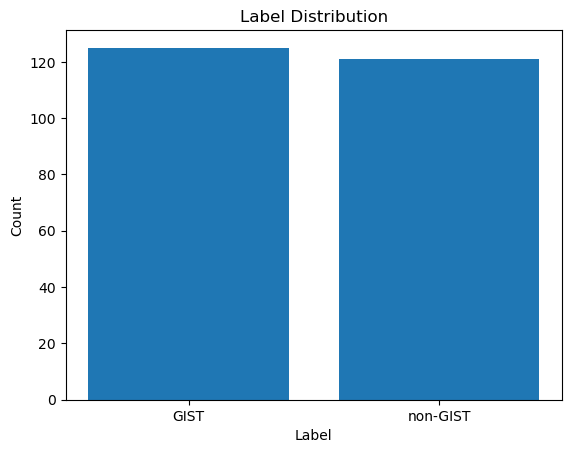

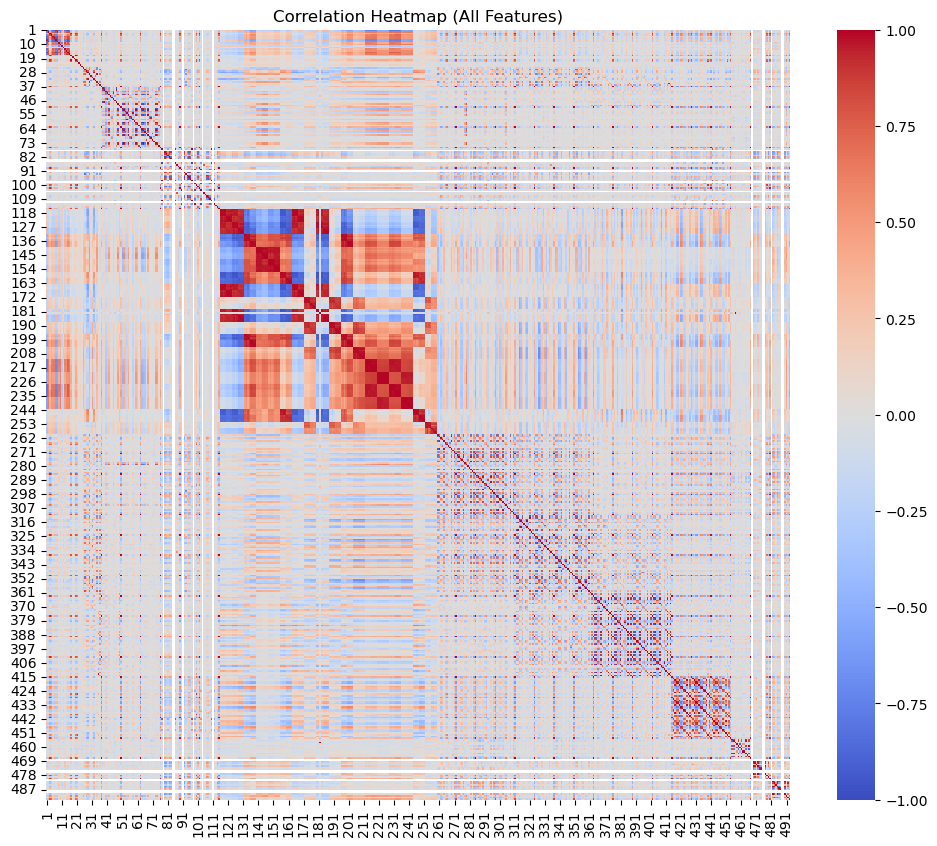


--- Normality and Outlier Check ---
Normally distributed features (Shapiro-Wilk p > 0.05): 50 out of 493 (10.1%)
Total outliers detected across all features: 6206
Features containing at least one outlier: 422 out of 493


In [6]:
#----------Data Loading and Inspection-----------

# Data loading functions.
data = load_data()
print(f'The number of samples: {len(data.index)}')
print(f'The number of columns: {len(data.columns)}')

#Show missing data
total_missing = data.isnull().sum().sum()
print(f'\nTotal missing values: {total_missing}')
#Show data info
print("\n--- Data Info ---")
data.info()

#Show label distribution
print(f'\nLabel distribution:')
print(data['label'].value_counts())
plt.bar(data['label'].value_counts().index, data['label'].value_counts().values)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Label Distribution')
plt.show()

#Show data correlation
numeric_features = data.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_features.corr()
feature_numbers = range(1, len(corr_matrix.columns) + 1)

corr_matrix.columns = feature_numbers
corr_matrix.index = feature_numbers

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (All Features)')
plt.show()



# ---------- Normality and Outlier Check -----------
print("\n--- Normality and Outlier Check ---")

numeric_features = data.select_dtypes(include=['float64', 'int64'])
# if 'label' in numeric_features.columns:
#     numeric_features = numeric_features.drop('label', axis=1) # Exclude the label if it's numeric

normal_count = 0
outlier_counts = {}

for col in numeric_features.columns:
    # Drop missing values for the statistical test
    col_data = numeric_features[col].dropna()
    
    # 1. Normality Test (Shapiro-Wilk)
    # p > 0.05 means we cannot reject the null hypothesis (data looks normal)
    stat, p = stats.shapiro(col_data)
    if p > 0.05:
        normal_count += 1
        
    # 2. Outlier Detection (IQR Method)
    # This aligns perfectly with your choice of using a Robust Scaler
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
    outlier_counts[col] = len(outliers)

# Summarize Normality
total_features = len(numeric_features.columns)
print(f"Normally distributed features (Shapiro-Wilk p > 0.05): {normal_count} out of {total_features} ({round((normal_count/total_features)*100, 1)}%)")

# Summarize Outliers
total_outliers = sum(outlier_counts.values())
features_with_outliers = sum(1 for count in outlier_counts.values() if count > 0)
print(f"Total outliers detected across all features: {total_outliers}")
print(f"Features containing at least one outlier: {features_with_outliers} out of {total_features}")

The number of samples: 246
The number of columns: 494

Label encoding mapping: {'GIST': np.int64(0), 'non-GIST': np.int64(1)}

Training set size: 209 samples
Testing set size: 37 samples
Starting Nested Cross-Validation...


Outer CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Fitting 5 folds for each of 15 candidates, totalling 75 fits


Outer CV Folds:  20%|██        | 1/5 [00:03<00:14,  3.67s/it]

Fitting 5 folds for each of 15 candidates, totalling 75 fits


...

Outer CV Folds:  60%|██████    | 3/5 [00:15<00:10,  5.42s/it]

Fitting 5 folds for each of 15 candidates, totalling 75 fits


Outer CV Folds:  80%|████████  | 4/5 [00:19<00:04,  4.72s/it]

Fitting 5 folds for each of 15 candidates, totalling 75 fits


Outer CV Folds: 100%|██████████| 5/5 [00:23<00:00,  4.76s/it]


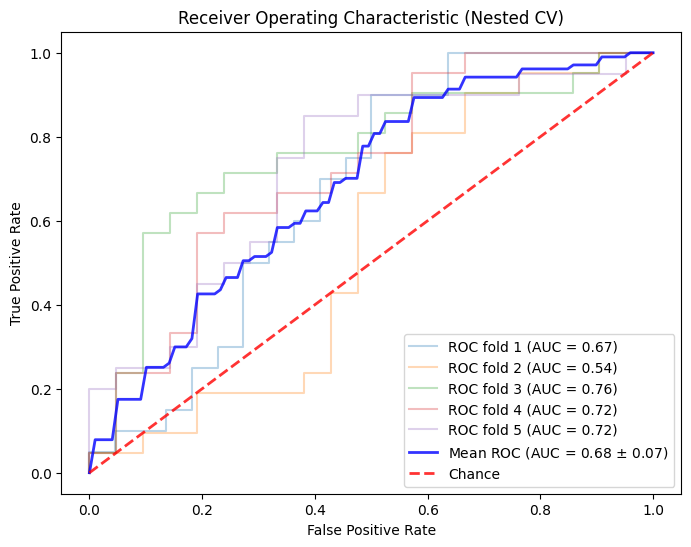


--- Summary of Best Models per Outer Fold ---


,Fold,Classifier,Feature Selector,After VarThresh,After CorrFilter,Final Features,Outer Accuracy,Outer AUC,Outer F1,Outer Sensitivity,Outer Specificity
0,1,RandomForestClassifier,MannWhitneyFilter,475,214,12,0.6429,0.6705,0.6667,0.7500,0.5455
1,2,RandomForestClassifier,RFE,474,206,16,0.5000,0.5442,0.4615,0.4286,0.5714
2,3,RandomForestClassifier,MannWhitneyFilter,476,208,12,0.7143,0.7574,0.7273,0.7619,0.6667
3,4,RandomForestClassifier,MannWhitneyFilter,476,207,18,0.6190,0.7211,0.6522,0.7143,0.5238
4,5,XGBClassifier,None,476,209,209,0.6341,0.7214,0.6154,0.6000,0.6667



--- Winning Hyperparameters per Fold ---

Fold 1 (12 features): RandomForestClassifier + MannWhitneyFilter
   - classifier: RandomForestClassifier
   - classifier__max_depth: 2
   - classifier__max_features: 0.2000
   - classifier__n_estimators: 156
   - feature_selection: MannWhitneyFilter
   - feature_selection__n_features_to_select: 12

Fold 2 (16 features): RandomForestClassifier + RFE
   - classifier: RandomForestClassifier
   - classifier__max_depth: 2
   - classifier__max_features: log2
   - classifier__n_estimators: 137
   - feature_selection: RFE
   - feature_selection__n_features_to_select: 16

Fold 3 (12 features): RandomForestClassifier + MannWhitneyFilter
   - classifier: RandomForestClassifier
   - classifier__max_depth: 2
   - classifier__max_features: 0.2000
   - classifier__n_estimators: 156
   - feature_selection: MannWhitneyFilter
   - feature_selection__n_features_to_select: 12

Fold 4 (18 features): RandomForestClassifier + MannWhitneyFilter
   - classifier: Rando

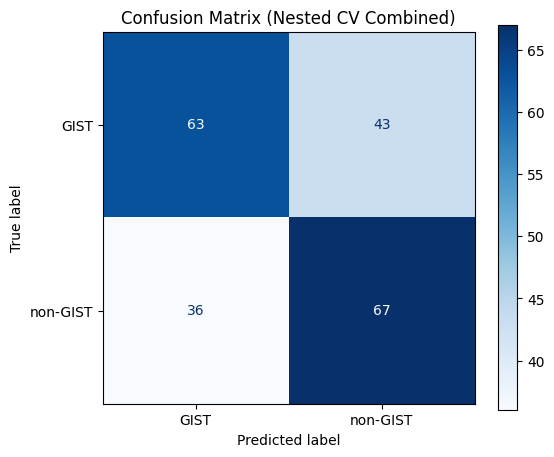


--- Generating Learning Curve ---


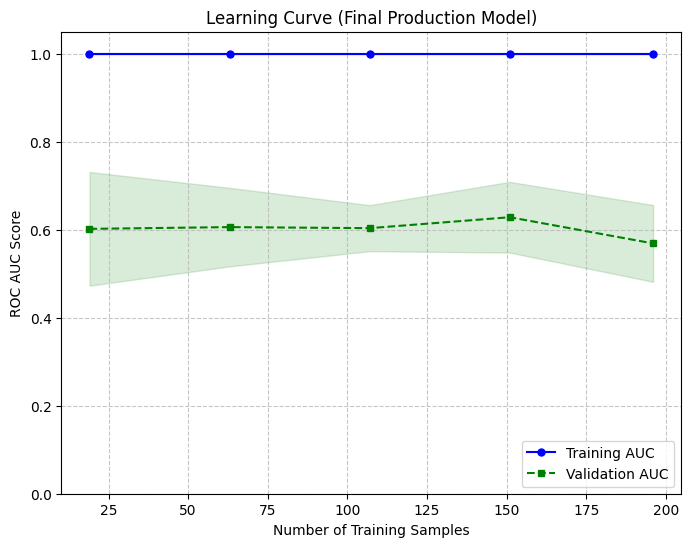

In [ ]:
# Data loading functions.
data = load_data()
print(f'The number of samples: {len(data.index)}')
print(f'The number of columns: {len(data.columns)}')
# ---------------------------------------------------------
# 1. Custom Transformers
# ---------------------------------------------------------
from sklearn.model_selection import learning_curve


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.to_drop = []

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop = [column for column in upper.columns if any(upper[column] > self.threshold)]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.drop(columns=self.to_drop)

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        lower_quantile = self.limits[0]
        upper_quantile = 1.0 - self.limits[1]
        self.lower_bounds_ = X_df.quantile(lower_quantile)
        self.upper_bounds_ = X_df.quantile(upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_winsorized = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        return X_winsorized

class MannWhitneyFilter(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select=10):
        self.n_features_to_select = n_features_to_select
        self.selected_indices_ = []

    def fit(self, X, y):
        X_df = pd.DataFrame(X)
        y_arr = np.array(y)
        class_0 = X_df[y_arr == 0]
        class_1 = X_df[y_arr == 1]
        p_values = []

        for col in X_df.columns:
            stat, p_val = mannwhitneyu(class_0[col], class_1[col], alternative='two-sided')
            p_values.append((col, p_val))

        p_values.sort(key=lambda x: x[1])
        k = min(self.n_features_to_select, len(X_df.columns))
        self.selected_indices_ = [item[0] for item in p_values[:k]]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df[self.selected_indices_]

# ---------------------------------------------------------
# 2. Data Preparation
# ---------------------------------------------------------
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
print(f'\nLabel encoding mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

# Train-test split (80-20 split, stratify on label)
X = data.drop(['label'], axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

print(f'\nTraining set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

# ---------------------------------------------------------
# 3. Dictionaries & Distributions
# ---------------------------------------------------------
feature_selectors = {
    'Mann-Whitney U-Test': MannWhitneyFilter(),
    'LASSO': SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42)),
    'RFE_LR': RFE(estimator=LogisticRegression(random_state=42), step=1),
    'None': 'passthrough'
}

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

param_distributions = [
    # Logistic Regression
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': loguniform(0.01, 10),
        'feature_selection__max_features': [25],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': loguniform(0.001, 100),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': loguniform(0.001, 100),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': loguniform(0.01, 10),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': loguniform(0.01, 10),
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },

    # Random Forest
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': loguniform(0.01, 10),
        'feature_selection__max_features': [25],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 5, 10],
        'classifier__max_features': ['sqrt', 'log2', 0.2, 0.4]
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 5, 10],
        'classifier__max_features': ['sqrt', 'log2', 0.2, 0.4]
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 5, 10],
        'classifier__max_features': ['sqrt', 'log2', 0.2, 0.4]
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 5, 10],
        'classifier__max_features': ['sqrt', 'log2', 0.2, 0.4]
    },

    # SVM
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': loguniform(0.01, 10),
        'feature_selection__max_features': [25],
        'classifier': [classifiers['SVM']],
        'classifier__C': loguniform(0.01, 100),
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['SVM']],
        'classifier__C': loguniform(0.01, 100),
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['SVM']],
        'classifier__C': loguniform(0.01, 100),
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['SVM']],
        'classifier__C': loguniform(0.01, 100),
        'classifier__kernel': ['linear', 'rbf']
    },

    # XGBoost
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': loguniform(0.01, 10),
        'feature_selection__max_features': [25],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': loguniform(0.01, 0.2),
        'classifier__subsample': [0.6,0.8, 1.0]

        
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': loguniform(0.01, 0.2),
        'classifier__subsample': [0.6, 0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': randint(5, 25),
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': loguniform(0.01, 0.2),
        'classifier__subsample': [0.6,0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': loguniform(0.01, 0.2),
        'classifier__subsample': [0.6,0.8, 1.0]
    }
]


# ---------------------------------------------------------
# 4. Pipeline & Search Setup
# ---------------------------------------------------------
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('variance_thresh', VarianceThreshold(threshold=0).set_output(transform="pandas")),
    ('scaler', RobustScaler().set_output(transform="pandas")),
    ('winsorizer', Winsorizer(limits=(0.01, 0.01))),
    ('corr_filter', CorrelationFilter(threshold=0.90)),
    ('feature_selection', 'passthrough'), 
    ('classifier', 'passthrough')        
])


inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Number of random combinations to test
N_ITER = 15

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=N_ITER,
    cv=inner_cv,
    scoring=['accuracy', 'roc_auc'],
    refit='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

#Nested loop
# ---------------------------------------------------------
# 5. Nested Loop Execution
# ---------------------------------------------------------
print("Starting Nested Cross-Validation...")

# Define the outer CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for plotting and the final table
fold_results = []
tprs = []
aucs = []
all_y_test = []
all_y_pred = []
mean_fpr = np.linspace(0, 1, 100)

# Setup the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Execute the manual outer loop
for fold, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y), total=outer_cv.get_n_splits(), desc="Outer CV Folds")):
    
    # Split the data for this specific fold
    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]
    
    # Run the inner RandomizedSearchCV to find the best model for this training fold
    random_search.fit(X_train_outer, y_train_outer)
    
    # Extract the best model
    best_model = random_search.best_estimator_
    best_params = random_search.best_params_
    
    # Calculate features remaining after VarianceThreshold
    # get_support() returns a boolean array of features that were kept
    var_thresh_step = best_model.named_steps['variance_thresh']
    features_after_var = sum(var_thresh_step.get_support())
    
    # Calculate features remaining after CorrelationFilter
    # It drops features from the input it received (which is the output of var_thresh)
    corr_filter_step = best_model.named_steps['corr_filter']
    features_after_corr = features_after_var - len(corr_filter_step.to_drop)

    # Evaluate the best model on the hidden outer test fold
    y_pred = best_model.predict(X_test_outer)
    y_prob = best_model.predict_proba(X_test_outer)[:, 1]
    
    # Calculate standard fold metrics
    fold_acc = accuracy_score(y_test_outer, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test_outer, y_prob)
    fold_auc = auc(fpr, tpr)
    
    # Calculate F1-score
    fold_f1 = f1_score(y_test_outer, y_pred)
    
    # Calculate Sensitivity and Specificity
    tn, fp, fn, tp = confusion_matrix(y_test_outer, y_pred).ravel()
    fold_sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fold_specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # Extract the final number of features used by the classifier
    fold_num_features = best_model.named_steps['classifier'].n_features_in_

    # Save true and predicted labels for the cumulative confusion matrix
    all_y_test.extend(y_test_outer)
    all_y_pred.extend(y_pred)
    
    # Save the ROC curve data
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(fold_auc)
    
    # Plot the ROC curve
    ax.plot(fpr, tpr, alpha=0.3, label=f'ROC fold {fold+1} (AUC = {fold_auc:.2f})')
    
    # Clean up names for the table
    classifier_name = str(best_model.named_steps['classifier'].__class__.__name__)
    feature_selector_name = str(best_model.named_steps['feature_selection'].__class__.__name__)
    if feature_selector_name == "str": 
        feature_selector_name = "None"
        
    # Store the results for the summary table
    fold_results.append({
        'Fold': fold + 1,
        'Classifier': classifier_name,
        'Feature Selector': feature_selector_name,
        'After VarThresh': features_after_var,
        'After CorrFilter': features_after_corr,
        'Final Features': fold_num_features,
        'Outer Accuracy': round(fold_acc, 4),
        'Outer AUC': round(fold_auc, 4),
        'Outer F1': round(fold_f1, 4),
        'Outer Sensitivity': round(fold_sensitivity, 4),
        'Outer Specificity': round(fold_specificity, 4),
        'Best Params (Raw)': best_params
    })

# Plot the Mean ROC curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=0.8)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)

# Finalize the plot formatting
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05], title="Receiver Operating Characteristic (Nested CV)")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc="lower right")
plt.show()

# ---------------------------------------------------------
# 6. Summary Table Output
# ---------------------------------------------------------
print("\n--- Summary of Best Models per Outer Fold ---")
results_df = pd.DataFrame(fold_results)

# Display the clean table
display(results_df.drop(columns=['Best Params (Raw)']))

# Display the winning hyperparameters for each fold
print("\n--- Winning Hyperparameters per Fold ---")
for index, row in results_df.iterrows():
    print(f"\nFold {row['Fold']} ({row['Final Features']} features): {row['Classifier']} + {row['Feature Selector']}")
    for param_name, param_value in row['Best Params (Raw)'].items():
        if hasattr(param_value, '__class__') and not isinstance(param_value, (int, float, str, bool, type(None))):
            print(f"   - {param_name}: {param_value.__class__.__name__}")
        elif isinstance(param_value, float):
            print(f"   - {param_name}: {param_value:.4f}")
        else:
            print(f"   - {param_name}: {param_value}")

# Calculate and print the unbiased overall metrics
print("\n--- Unbiased Overall Performance ---")
print(f"Mean Features after VarThresh: {results_df['After VarThresh'].mean():.1f} (+/- {results_df['After VarThresh'].std():.1f})")
print(f"Mean Features after CorrFilter: {results_df['After CorrFilter'].mean():.1f} (+/- {results_df['After CorrFilter'].std():.1f})")
print(f"Mean Final Features Used:      {results_df['Final Features'].mean():.1f} (+/- {results_df['Final Features'].std():.1f})")
print(f"Mean Nested Accuracy:          {results_df['Outer Accuracy'].mean():.4f} (+/- {results_df['Outer Accuracy'].std():.4f})")
print(f"Mean Nested AUC:               {results_df['Outer AUC'].mean():.4f} (+/- {results_df['Outer AUC'].std():.4f})")
print(f"Mean Nested F1-Score:          {results_df['Outer F1'].mean():.4f} (+/- {results_df['Outer F1'].std():.4f})")
print(f"Mean Nested Sensitivity:       {results_df['Outer Sensitivity'].mean():.4f} (+/- {results_df['Outer Sensitivity'].std():.4f})")
print(f"Mean Nested Specificity:       {results_df['Outer Specificity'].mean():.4f} (+/- {results_df['Outer Specificity'].std():.4f})")
# ---------------------------------------------------------
# 7. Cumulative Confusion Matrix Plot
# ---------------------------------------------------------
print("\n--- Cumulative Confusion Matrix (All Folds Combined) ---")

# Bereken de matrix
cm = confusion_matrix(all_y_test, all_y_pred)

# Zet de plot op met een mooie kleurenschaal (Blues)
fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax_cm, values_format='d')

plt.title("Confusion Matrix (Nested CV Combined)")
plt.show()

# ---------------------------------------------------------
# 8. Learning Curve Analysis
# ---------------------------------------------------------
print("\n--- Generating Learning Curve ---")

# Extract the final winning model architecture
final_model = random_search.best_estimator_

# Calculate the learning curve scores
# We use the same outer_cv strategy to ensure consistent evaluation
# train_sizes controls the percentage of data used at each step (from 10% to 100%)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=final_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=outer_cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Calculate the mean and standard deviation across all folds for the training data
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate the mean and standard deviation across all folds for the validation data
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Set up the plot aesthetics
plt.figure(figsize=(8, 6))

# Plot the training performance line and its variance (standard deviation)
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training AUC')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

# Plot the validation performance line and its variance
plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation AUC')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

# Add labels, title, and formatting to the plot
plt.title('Learning Curve (Final Production Model)')
plt.xlabel('Number of Training Samples')
plt.ylabel('ROC AUC Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.ylim([0.0, 1.05])

# Display the final plot
plt.show()



--- Generating Learning Curve ---


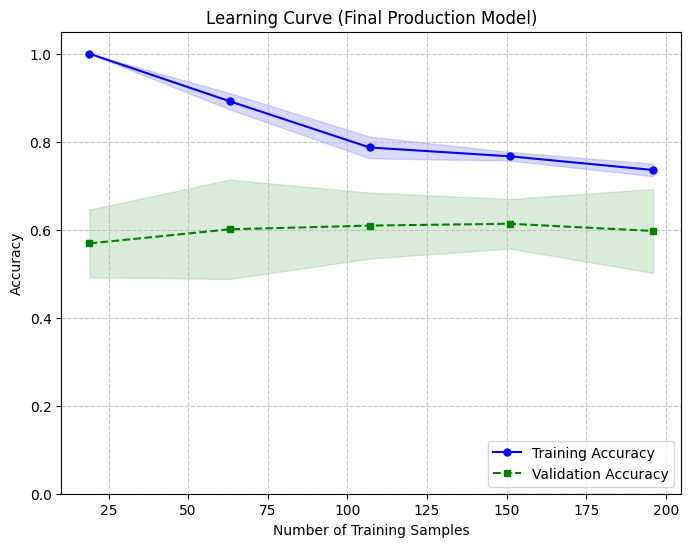

In [9]:
# ---------------------------------------------------------
# 8. Learning Curve Analysis
# ---------------------------------------------------------
print("\n--- Generating Learning Curve ---")

# Extract the final winning model architecture
final_model = random_search.best_estimator_

# Calculate the learning curve scores
# We use the same outer_cv strategy to ensure consistent evaluation
# train_sizes controls the percentage of data used at each step (from 10% to 100%)
train_sizes, train_scores, test_scores = learning_curve(
    estimator=final_model,
    X=X,
    y=y,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=outer_cv,
    scoring='accuracy',
    n_jobs=-1
)

# Calculate the mean and standard deviation across all folds for the training data
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate the mean and standard deviation across all folds for the validation data
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Set up the plot aesthetics
plt.figure(figsize=(8, 6))

# Plot the training performance line and its variance (standard deviation)
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

# Plot the validation performance line and its variance
plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation Accuracy')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

# Add labels, title, and formatting to the plot
plt.title('Learning Curve (Final Production Model)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.ylim([0.0, 1.05])

# Display the final plot
plt.show()


--- Extracting Feature Importances ---


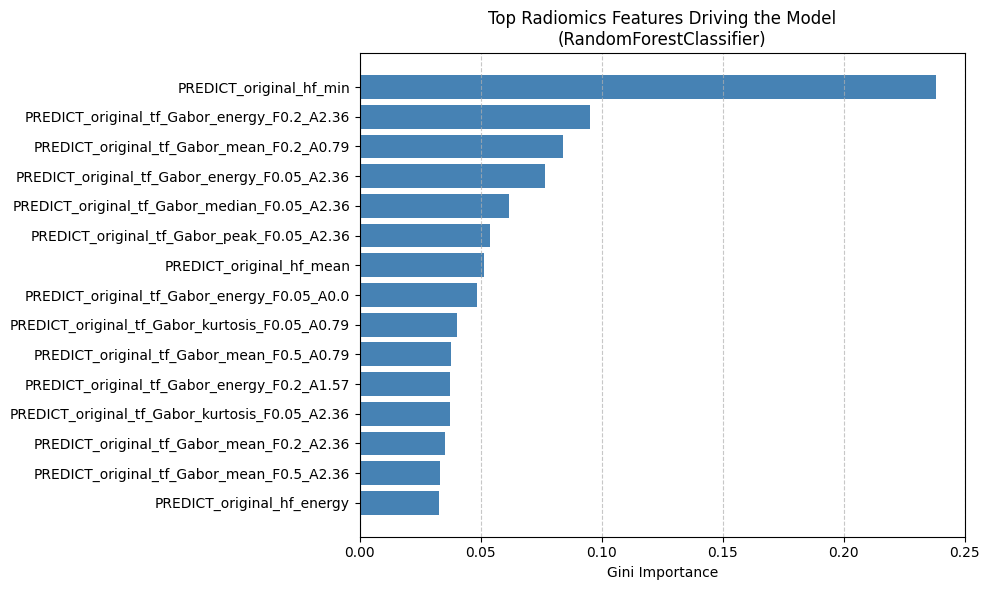


Top 10 Most Important Features:


,Feature,Importance
0,PREDICT_original_hf_min,0.238166
1,PREDICT_original_tf_Gabor_energy_F0.2_A2.36,0.095228
2,PREDICT_original_tf_Gabor_mean_F0.2_A0.79,0.083768
3,PREDICT_original_tf_Gabor_energy_F0.05_A2.36,0.076643
4,PREDICT_original_tf_Gabor_median_F0.05_A2.36,0.061656
5,PREDICT_original_tf_Gabor_peak_F0.05_A2.36,0.053828
6,PREDICT_original_hf_mean,0.051396
7,PREDICT_original_tf_Gabor_energy_F0.05_A0.0,0.048560
8,PREDICT_original_tf_Gabor_kurtosis_F0.05_A0.79,0.040015
9,PREDICT_original_tf_Gabor_mean_F0.5_A0.79,0.037701


In [11]:
print("\n--- Extracting Feature Importances ---")

# Extract the final trained pipeline and its core components
final_pipeline = random_search.best_estimator_
classifier = final_pipeline.named_steps['classifier']

# 1. Get feature names after VarianceThreshold
# VT drops columns with zero variance. We save the surviving original names.
vt = final_pipeline.named_steps['variance_thresh']
vt_support = vt.get_support()
features_after_vt = np.array(X.columns)[vt_support]

# 2. Map the current pipeline column names to the real feature names
# Since Scaler and Winsorizer do NOT drop columns, the order remains exactly the same.
winsorizer = final_pipeline.named_steps['winsorizer']
winsor_cols = winsorizer.lower_bounds_.index.tolist()

# Create a robust dictionary linking the internal pipeline name (e.g., 'x0') to the real name
real_names_dict = {}
for i, col in enumerate(winsor_cols):
    real_names_dict[col] = features_after_vt[i]

# 3. Filter out features dropped by CorrelationFilter
corr_filter = final_pipeline.named_steps['corr_filter']
remaining_cols = [c for c in winsor_cols if c not in corr_filter.to_drop]
features_after_corr = [real_names_dict[c] for c in remaining_cols]

# 4. Filter out features dropped by the specific Feature Selector
fs = final_pipeline.named_steps['feature_selection']
if fs == 'passthrough':
    final_feature_names = features_after_corr
elif hasattr(fs, 'get_support'):
    # For Scikit-Learn selectors like RFE and LASSO (SelectFromModel)
    fs_support = fs.get_support()
    final_feature_names = np.array(features_after_corr)[fs_support].tolist()
elif hasattr(fs, 'selected_indices_'):
    # For the custom Mann-Whitney Filter
    final_feature_names = [real_names_dict[c] for c in fs.selected_indices_]
else:
    final_feature_names = features_after_corr
    
# 5. Extract mathematical importances from the classifier
if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    metric_name = "Gini Importance"
elif hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0])
    metric_name = "Absolute Coefficient Value"
else:
    print("The selected classifier does not have easily extractable feature importances.")
    importances = np.zeros(len(final_feature_names))
    metric_name = "Unknown"

# 6. Create DataFrame and Plot
importance_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Keep only the top 15 features to prevent clutter
top_features = importance_df.tail(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
plt.xlabel(metric_name)
plt.title(f'Top Radiomics Features Driving the Model\n({classifier.__class__.__name__})')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print the exact values in a clean table
print("\nTop 10 Most Important Features:")
display(importance_df.sort_values(by='Importance', ascending=False).head(10).reset_index(drop=True))


Label encoding mapping: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Training set size: 196 samples
Testing set size: 50 samples
Starting Nested Cross-Validation...


Outer CV Folds:   0%|          | 0/5 [00:00<?, ?it/s]

Fitting 10 folds for each of 1398 candidates, totalling 13980 fits


Outer CV Folds:  20%|██        | 1/5 [25:50<1:43:21, 1550.25s/it]

Fitting 10 folds for each of 1398 candidates, totalling 13980 fits


...

Outer CV Folds:  60%|██████    | 3/5 [2:04:00<1:26:08, 2584.03s/it]

Fitting 10 folds for each of 1398 candidates, totalling 13980 fits


Outer CV Folds:  80%|████████  | 4/5 [3:35:44<1:02:16, 3736.61s/it]

Fitting 10 folds for each of 1398 candidates, totalling 13980 fits


Outer CV Folds: 100%|██████████| 5/5 [4:02:56<00:00, 2915.35s/it]  


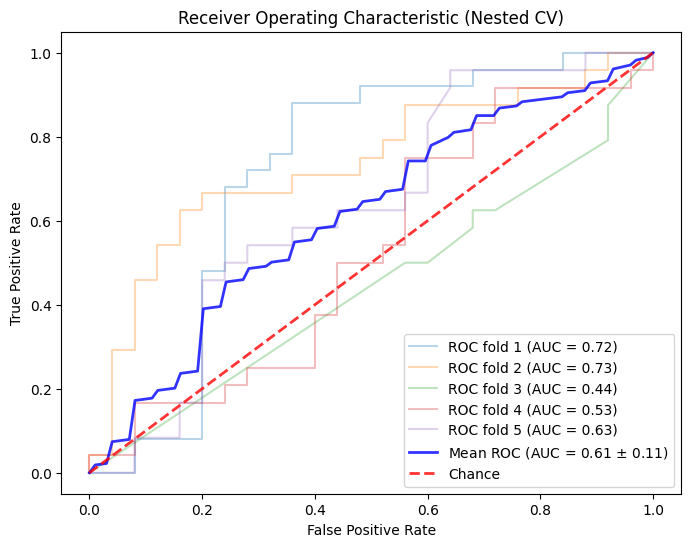


--- Summary of Best Models per Outer Fold ---


,Fold,Classifier,Feature Selector,Outer Accuracy,Outer AUC
0,1,XGBClassifier,RFE,0.7200,0.7184
1,2,XGBClassifier,RFE,0.6327,0.7350
2,3,XGBClassifier,SelectFromModel,0.4694,0.4450
3,4,XGBClassifier,None,0.4898,0.5267
4,5,XGBClassifier,MannWhitneyFilter,0.5714,0.6283



--- Winning Hyperparameters per Fold ---

Fold 1: XGBClassifier + RFE
   - classifier: XGBClassifier
   - classifier__learning_rate: 0.1000
   - classifier__max_depth: 4
   - classifier__n_estimators: 200
   - classifier__subsample: 1.0000
   - feature_selection: RFE
   - feature_selection__n_features_to_select: 100

Fold 2: XGBClassifier + RFE
   - classifier: XGBClassifier
   - classifier__learning_rate: 0.2000
   - classifier__max_depth: 2
   - classifier__n_estimators: 100
   - classifier__subsample: 0.8000
   - feature_selection: RFE
   - feature_selection__n_features_to_select: 70

Fold 3: XGBClassifier + SelectFromModel
   - classifier: XGBClassifier
   - classifier__learning_rate: 0.0100
   - classifier__max_depth: 2
   - classifier__n_estimators: 50
   - classifier__subsample: 1.0000
   - feature_selection: SelectFromModel
   - feature_selection__estimator__C: 0.1000

Fold 4: XGBClassifier + None
   - classifier: XGBClassifier
   - classifier__learning_rate: 0.2000
   - class

In [16]:

# ---------------------------------------------------------
# 1. Custom Transformers
# ---------------------------------------------------------
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90):
        self.threshold = threshold
        self.to_drop = []

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        corr_matrix = X_df.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop = [column for column in upper.columns if any(upper[column] > self.threshold)]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.drop(columns=self.to_drop)

class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        lower_quantile = self.limits[0]
        upper_quantile = 1.0 - self.limits[1]
        self.lower_bounds_ = X_df.quantile(lower_quantile)
        self.upper_bounds_ = X_df.quantile(upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_winsorized = X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)
        return X_winsorized

class MannWhitneyFilter(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select=10):
        self.n_features_to_select = n_features_to_select
        self.selected_indices_ = []

    def fit(self, X, y):
        X_df = pd.DataFrame(X)
        y_arr = np.array(y)
        class_0 = X_df[y_arr == 0]
        class_1 = X_df[y_arr == 1]
        p_values = []

        for col in X_df.columns:
            stat, p_val = mannwhitneyu(class_0[col], class_1[col], alternative='two-sided')
            p_values.append((col, p_val))

        p_values.sort(key=lambda x: x[1])
        k = min(self.n_features_to_select, len(X_df.columns))
        self.selected_indices_ = [item[0] for item in p_values[:k]]
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df[self.selected_indices_]

# ---------------------------------------------------------
# 2. Data Preparation
# ---------------------------------------------------------
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['label'])
print(f'\nLabel encoding mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}')

# Train-test split (80-20 split, stratify on label)
X = data.drop(['label'], axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'\nTraining set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')

# ---------------------------------------------------------
# 3. Dictionaries & Distributions
# ---------------------------------------------------------
feature_selectors = {
    'Mann-Whitney U-Test': MannWhitneyFilter(),
    'LASSO': SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42)),
    'RFE_LR': RFE(estimator=LogisticRegression(random_state=42), step=0.05),
    'None': 'passthrough'
}

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

param_grid = [
    # Logistic Regression
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': [0.001, 0.1, 10.0, 100.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': [0.001, 0.1, 10.0, 100.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['Logistic Regression']],
        'classifier__C': [0.01, 0.1, 1.0, 10.0],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear']
    },

    # Random Forest
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 5, 10]
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['Random Forest']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 5, 10]
    },

    # SVM
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'classifier': [classifiers['SVM']],
        'classifier__C': [0.01, 1.0, 100.0],
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['SVM']],
        'classifier__C': [0.01, 1.0, 100.0],
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': [5, 10, 15, 20, 25],
        'classifier': [classifiers['SVM']],
        'classifier__C': [0.01, 1.0, 100.0],
        'classifier__kernel': ['linear', 'rbf']
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['SVM']],
        'classifier__C': [0.01, 1.0, 100.0],
        'classifier__kernel': ['linear', 'rbf']
    },

    # XGBoost
    {
        'feature_selection': [feature_selectors['LASSO']],
        'feature_selection__estimator__C': [0.01, 0.1, 1.0, 10.0],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['RFE_LR']],
        'feature_selection__n_features_to_select': [10, 40, 70, 100], 
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['Mann-Whitney U-Test']],
        'feature_selection__n_features_to_select': [10, 40, 70, 100],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0]
    },
    {
        'feature_selection': [feature_selectors['None']],
        'classifier': [classifiers['XGBoost']],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [2, 3, 4],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__subsample': [0.6, 0.8, 1.0]
    }
]


# ---------------------------------------------------------
# 4. Pipeline & Search Setup
# ---------------------------------------------------------
pipeline = Pipeline([
    ('variance_thresh', VarianceThreshold(threshold=0).set_output(transform="pandas")),
    ('scaler', RobustScaler().set_output(transform="pandas")),
    ('winsorizer', Winsorizer(limits=(0.01, 0.01))),
    ('corr_filter', CorrelationFilter(threshold=0.90)),
    ('feature_selection', 'passthrough'), 
    ('classifier', 'passthrough')        
])

inner_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Replaced RandomizedSearchCV with GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=inner_cv,
    scoring=['accuracy', 'roc_auc'],
    refit='accuracy',
    n_jobs=-1,
    verbose=1
)

#Nested loop

print("Starting Nested Cross-Validation...")

# Define the outer CV
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Lists to store metrics for plotting and the final table
fold_results = []
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

# Setup the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Execute the manual outer loop
# We use tqdm here to show progress across the 5 outer folds
for fold, (train_idx, test_idx) in enumerate(tqdm(outer_cv.split(X, y), total=outer_cv.get_n_splits(), desc="Outer CV Folds")):
    
    # Split the data for this specific fold
    # Note: Use .iloc if X and y are Pandas DataFrames/Series to avoid index errors
    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]
    
    # Run the inner RandomizedSearchCV to find the best model for this training fold
    grid_search.fit(X_train_outer, y_train_outer)
    
    # Extract the best model
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # Evaluate the best model on the hidden outer test fold
    y_pred = best_model.predict(X_test_outer)
    y_prob = best_model.predict_proba(X_test_outer)[:, 1]
    
    # Calculate fold metrics
    fold_acc = accuracy_score(y_test_outer, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test_outer, y_prob)
    fold_auc = auc(fpr, tpr)
    
    # Save the ROC curve data for the mean plot later
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(fold_auc)
    
    # Plot the ROC curve for this specific fold
    ax.plot(fpr, tpr, alpha=0.3, label=f'ROC fold {fold+1} (AUC = {fold_auc:.2f})')
    
    # Clean up the best_params dictionary for the table (make it easier to read)
    classifier_name = str(best_model.named_steps['classifier'].__class__.__name__)
    feature_selector_name = str(best_model.named_steps['feature_selection'].__class__.__name__)
    if feature_selector_name == "str": # Handles the 'passthrough' string
        feature_selector_name = "None"
        
    # Store the results for the summary table
    fold_results.append({
        'Fold': fold + 1,
        'Classifier': classifier_name,
        'Feature Selector': feature_selector_name,
        'Outer Accuracy': round(fold_acc, 4),
        'Outer AUC': round(fold_auc, 4),
        'Best Params (Raw)': best_params
    })

# Plot the Mean ROC curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
        lw=2, alpha=0.8)

# Plot the random chance line (diagonal)
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)

# Finalize the plot formatting
ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="Receiver Operating Characteristic (Nested CV)")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc="lower right")
plt.show()

# ---------------------------------------------------------
# 6. Summary Table Output
# ---------------------------------------------------------
print("\n--- Summary of Best Models per Outer Fold ---")
results_df = pd.DataFrame(fold_results)

# Display the clean table
display(results_df.drop(columns=['Best Params (Raw)']))

# Display the winning hyperparameters for each fold
print("\n--- Winning Hyperparameters per Fold ---")
for index, row in results_df.iterrows():
    print(f"\nFold {row['Fold']}: {row['Classifier']} + {row['Feature Selector']}")
    #Iterate through the dictionary and print the exact parameter names
    for param_name, param_value in row['Best Params (Raw)'].items():
        # If the value is a complex object (like the classifier itself), print its class name
        if hasattr(param_value, '__class__') and not isinstance(param_value, (int, float, str, bool, type(None))):
            print(f"   - {param_name}: {param_value.__class__.__name__}")
        elif isinstance(param_value, float):
            # Format floats to 4 decimal places for readability
            print(f"   - {param_name}: {param_value:.4f}")
        else:
            # Print strings, ints, and booleans exactly as they are
            print(f"   - {param_name}: {param_value}")

# Calculate and print the unbiased overall metrics
print("\n--- Unbiased Overall Performance ---")
print(f"Mean Nested Accuracy: {results_df['Outer Accuracy'].mean():.4f} (+/- {results_df['Outer Accuracy'].std():.4f})")
print(f"Mean Nested AUC:      {results_df['Outer AUC'].mean():.4f} (+/- {results_df['Outer AUC'].std():.4f})")

Fitting 10 folds for each of 324 candidates, totalling 3240 fits
Generating cross-validated predictions...


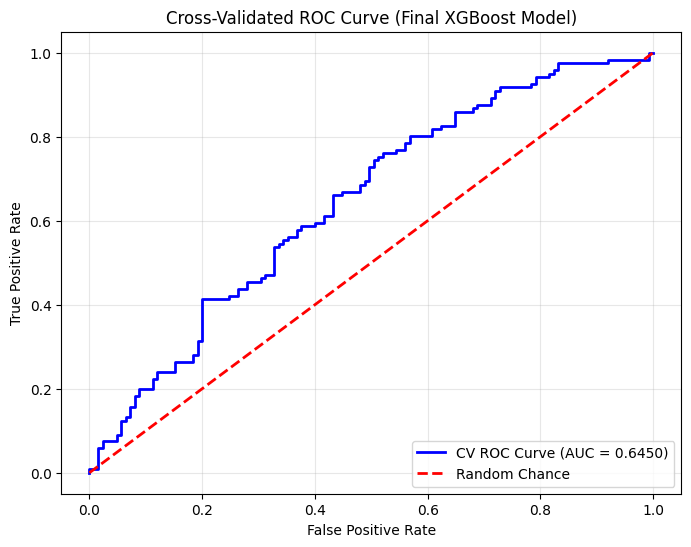


Extracting selected features and their importance...

--- Final Model Selected Features ---
Total features selected: 30


,Feature,Importance
0,PREDICT_original_tf_Gabor_min_F0.2_A0.79,0.058237
1,PREDICT_original_tf_Gabor_mean_F0.5_A2.36,0.048142
2,PREDICT_original_tf_Gabor_peak_F0.05_A2.36,0.047784
3,PREDICT_original_tf_GLCMMS_homogeneityd3.0A0.0...,0.047251
4,PREDICT_original_tf_Gabor_quartile_range_F0.2_...,0.046310
5,PREDICT_original_sf_rad_dist_std_2.5D,0.043744
6,PREDICT_original_tf_Gabor_skewness_F0.5_A2.36,0.039732
7,PREDICT_original_hf_max,0.038821
8,PREDICT_original_logf_skewness_sigma10,0.038355
9,PREDICT_original_tf_GLCM_contrastd1.0A0.0,0.037495


In [7]:
# 1. Define the exact pipeline structure that won the nested CV
pipeline_final = Pipeline([
    ('variance_thresh', VarianceThreshold(threshold=0).set_output(transform="pandas")),
    ('scaler', RobustScaler().set_output(transform="pandas")),
    ('winsorizer', Winsorizer(limits=(0.01, 0.01))),
    ('corr_filter', CorrelationFilter(threshold=0.90)),
    ('feature_selection', RFE(estimator=LogisticRegression(random_state=42), step=0.05)), 
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))        
])

# 2. Define the specific grid for this combination only
param_grid_final = {
    'feature_selection__n_features_to_select': [10, 20, 30, 40],
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [2, 3, 4],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0]
}

# 3. Setup a robust cross-validation scheme (e.g., 5 or 10 folds)
cv_final = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 4. Initialize the final GridSearch
grid_search_final = GridSearchCV(
    estimator=pipeline_final,
    param_grid=param_grid_final,
    cv=cv_final,
    scoring='roc_auc', # Optimize directly for AUC now
    n_jobs=-1,
    verbose=1
)

# 5. Fit the model on the ENTIRE dataset (X, y)
# The internal CV ensures we do not overfit during parameter selection
grid_search_final.fit(X, y)

# Retrieve the absolute best model ready for production
best_final_model = grid_search_final.best_estimator_


# 1. Generate out-of-fold predictions for an honest ROC curve
print("Generating cross-validated predictions...")
y_prob_cv = cross_val_predict(
    best_final_model, 
    X, 
    y, 
    cv=cv_final, 
    method='predict_proba', 
    n_jobs=-1
)[:, 1]

# Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(y, y_prob_cv)
roc_auc = auc(fpr, tpr)

# 2. Plot the Cross-Validated ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', lw=2, label=f'CV ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Chance')

ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Cross-Validated ROC Curve (Final XGBoost Model)')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.show()

# 3. Extract Feature Importances and Names
print("\nExtracting selected features and their importance...")

# Push the original data through the pipeline steps up to the feature selector
# This ensures we have the exact column names that were passed to the RFE
X_var = best_final_model.named_steps['variance_thresh'].transform(X)
X_scaled = best_final_model.named_steps['scaler'].transform(X_var)
X_win = best_final_model.named_steps['winsorizer'].transform(X_scaled)
X_corr = best_final_model.named_steps['corr_filter'].transform(X_win)

# Get the feature names that went into the RFE selector
features_into_rfe = X_corr.columns

# Get the boolean mask of features that RFE actually kept
rfe_mask = best_final_model.named_steps['feature_selection'].support_
selected_feature_names = features_into_rfe[rfe_mask]

# Get the importance scores from the XGBoost classifier
xgb_importances = best_final_model.named_steps['classifier'].feature_importances_

# 4. Create and display the summary table
importance_df = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': xgb_importances
})

# Sort by importance (highest first) and reset the index for a clean table
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("\n--- Final Model Selected Features ---")
print(f"Total features selected: {len(selected_feature_names)}")
display(importance_df)